# Converted Mathematica PDE notebook (original, non-smoothed initial conditions)

This notebook is a Python translation of the Mathematica workflow using the **original piecewise initial conditions**:

- `f(r) = m/a` for `r < LeeL`, and `(m/a) exp(-(r-LeeL))` for `r >= LeeL`
- `g(r) = A sin(pi r / LeeL) / r` for `r < LeeL`, and `0` for `r >= LeeL`

It includes:

- the original piecewise initial data
- a radial finite-difference PDE solver
- plots of the initial profiles
- a time-series plot of `phi(LeeL, t)`
- static snapshots
- inline animations for `phi(r,t)`, `u(r,t)`, and `v(r,t)`

This follows the earlier converted notebook, but **without** the C² smoothing patch.


In [109]:
import numpy as np
from dataclasses import dataclass
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams["animation.html"] = "jshtml"


In [110]:
@dataclass
class Params:
    m: float = 1.0
    a: float = 2.0
    LeeL: float = 10.0 * np.pi
    b: float = 0.1
    c: float = 0.1
    A: float = 120
    Lbox: float = 300.0
    tmax: float = 300.0
    r0: float = 1.0e-5
    nr: int = 800       # increase for higher resolution
    rtol: float = 1e-8
    atol: float = 1e-8


## Original piecewise initial data

In [111]:
def f_original(r, p: Params):
    r = np.asarray(r, dtype=float)
    out = np.zeros_like(r)
    mask = r < p.LeeL
    out[mask] = p.m / p.a
    out[~mask] = (p.m / p.a) * np.exp(-(r[~mask] - p.LeeL))
   # out[mask]=p.m/p.a* np.sin(np.pi * r[mask] / p.LeeL) / r[mask]
    return out

def g_original(r, p: Params):
    r = np.asarray(r, dtype=float)
    out = np.zeros_like(r)
    mask = r < p.LeeL
    out[mask] = p.A * np.sin(np.pi * r[mask] / p.LeeL) / r[mask]
    return out


## Radial finite-difference PDE system

In [112]:
def radial_laplacian(y, r, dr):
    y = np.asarray(y, dtype=float)
    lap = np.zeros_like(y)

    # Near the origin: regularity-inspired one-sided approximation
    lap[0] = 6.0 * (y[1] - y[0]) / dr**2

    # Interior points
    lap[1:-1] = (
        (y[2:] - 2.0 * y[1:-1] + y[:-2]) / dr**2
        + (y[2:] - y[:-2]) / ( dr * r[1:-1])
    )

    # Outer boundary: simple Dirichlet ghost point y(R)=0
    yR = 0.0
    lap[-1] = (
        (yR - 2.0 * y[-1] + y[-2]) / dr**2
        + (yR - y[-2]) / ( dr * r[-1])
    )
    return lap

def rhs(t, Y, p: Params, r, dr, n):
    phi  = Y[0:n]
    u    = Y[n:2*n]
    v    = Y[2*n:3*n]
    phit = Y[3*n:4*n]
    ut   = Y[4*n:5*n]
    vt   = Y[5*n:6*n]

    lap_phi = radial_laplacian(phi, r, dr)
    lap_u   = radial_laplacian(u, r, dr)
    lap_v   = radial_laplacian(v, r, dr)

    mass_sq = (p.a * phi - p.m)**2
    density = u**2 + v**2

    phi_tt = lap_phi - 2.0 * p.a * (p.a * phi - p.m) * density - 2.0 * p.b * phi - 4.0 * p.c * phi**3
    u_tt   = lap_u - mass_sq * u
    v_tt   = lap_v - mass_sq * v

    return np.concatenate([phit, ut, vt, phi_tt, u_tt, v_tt])

def solve_system(p: Params, n_times=2001, method="RK45"):
    r_full = np.linspace(p.r0, p.Lbox, p.nr)
    dr = r_full[1] - r_full[0]
    r = r_full[:-1]   # evolve all but the outer ghost/boundary location
    n = r.size

    phi0 = f_original(r, p)
    u0   = g_original(r, p)
    v0   = np.zeros_like(r)

    phit0 = np.zeros_like(r)
    ut0   = np.zeros_like(r)
    vt0   = (np.pi / p.LeeL) * g_original(r, p)

    y0 = np.concatenate([phi0, u0, v0, phit0, ut0, vt0])
    t_eval = np.linspace(0.0, p.tmax, n_times)

    sol = solve_ivp(
        rhs,
        (0.0, p.tmax),
        y0,
        t_eval=t_eval,
        args=(p, r, dr, n),
        method=method,
        rtol=p.rtol,
        atol=p.atol,
    )
    return r_full, r, sol

def unpack_solution(sol, n):
    phi = sol.y[0:n, :]
    u   = sol.y[n:2*n, :]
    v   = sol.y[2*n:3*n, :]
    phit = sol.y[3*n:4*n, :]
    ut   = sol.y[4*n:5*n, :]
    vt   = sol.y[5*n:6*n, :]
    return phi, u, v, phit, ut, vt


## Plot the original initial profiles

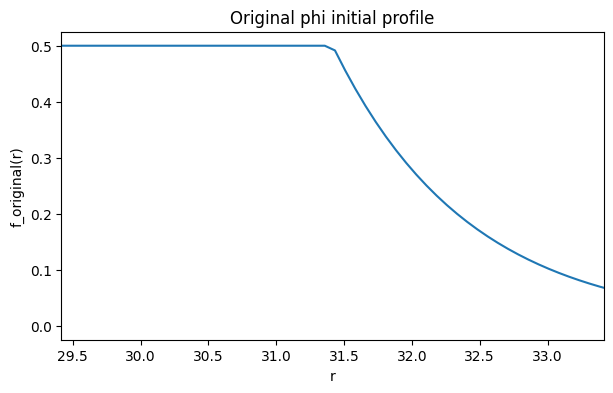

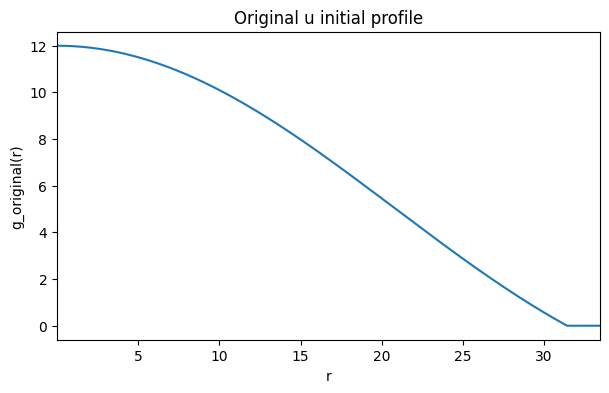

In [113]:
p = Params()

r_plot = np.linspace(p.r0, p.Lbox, 4000)

plt.figure(figsize=(7, 4))
plt.plot(r_plot, f_original(r_plot, p))
plt.xlim(max(p.r0, p.LeeL - 2.0), p.LeeL + 2.0)
plt.xlabel("r")
plt.ylabel("f_original(r)")
plt.title("Original phi initial profile")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(r_plot, g_original(r_plot, p))
plt.xlim(p.r0, p.LeeL + 2.0)
plt.xlabel("r")
plt.ylabel("g_original(r)")
plt.title("Original u initial profile")
plt.show()


## Solve the PDE system

In [114]:
# You can adjust p.nr, p.tmax, tolerances, and method before solving.
# For a stiffer problem, you might also try method="Radau" or method="BDF"."RK45"
p = Params()
r_full, r, sol = solve_system(p, n_times=701, method="RK45")

print("Success:", sol.success)
print("Message:", sol.message)
print("Time samples:", len(sol.t))
print("Spatial points:", len(r))


Success: True
Message: The solver successfully reached the end of the integration interval.
Time samples: 701
Spatial points: 799


In [115]:
n = len(r)
phi, u, v, phit, ut, vt = unpack_solution(sol, n)


## Plot $\phi(\mathrm{LeeL}, t)$

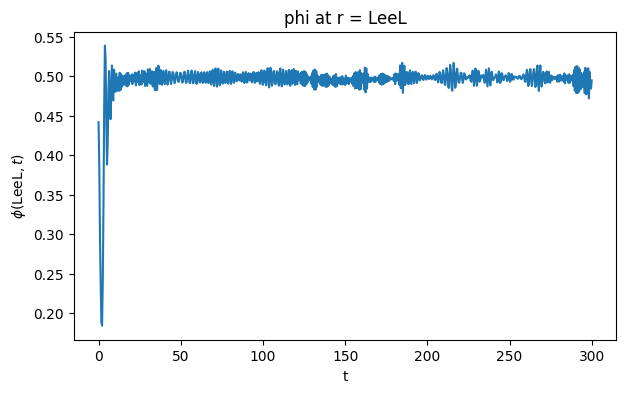

In [116]:
idx = np.argmin(np.abs(r - p.LeeL))

plt.figure(figsize=(7, 4))
plt.plot(sol.t, phi[idx, :])
plt.xlabel("t")
plt.ylabel(r"$\phi(\mathrm{LeeL}, t)$")
plt.title("phi at r = LeeL")
plt.show()


## Static snapshots

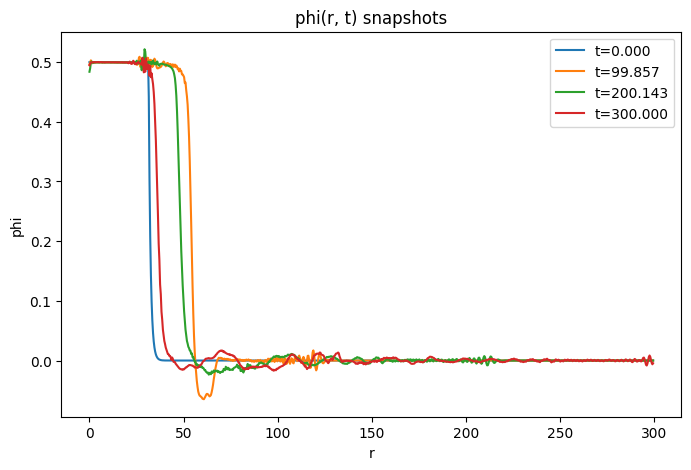

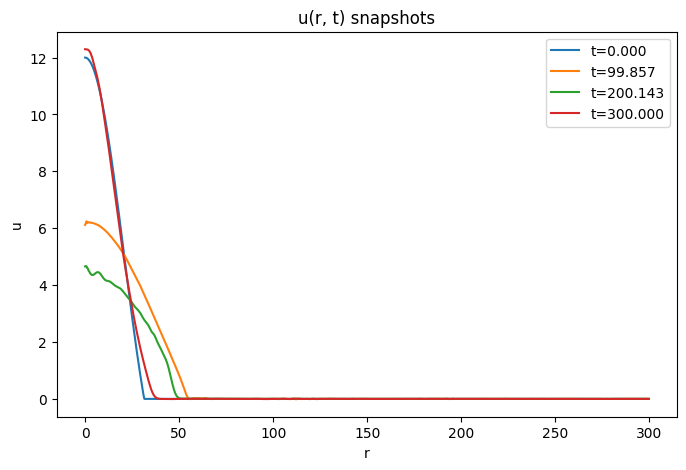

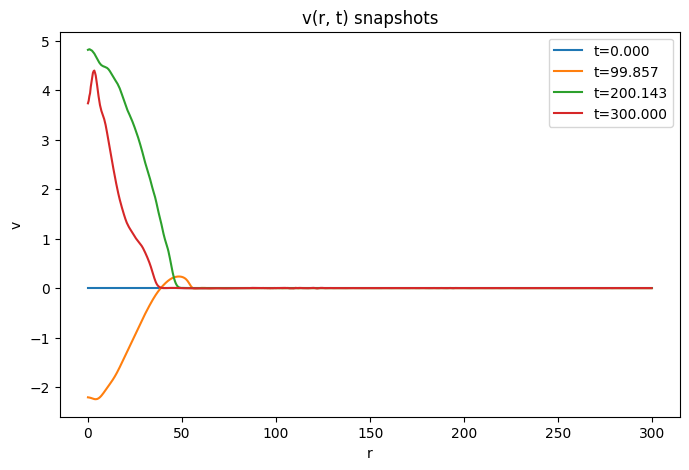

In [117]:
def plot_snapshots(sol, r, data, field_name, times=None):
    if times is None:
        times = [sol.t[0], sol.t[len(sol.t)//3], sol.t[2*len(sol.t)//3], sol.t[-1]]

    plt.figure(figsize=(8, 5))
    for t_target in times:
        i = np.argmin(np.abs(sol.t - t_target))
        plt.plot(r, data[:, i], label=f"t={sol.t[i]:.3f}")
    plt.xlabel("r")
    plt.ylabel(field_name)
    plt.title(f"{field_name}(r, t) snapshots")
    plt.legend()
    plt.show()

plot_snapshots(sol, r, phi, "phi")
plot_snapshots(sol, r, u, "u")
plot_snapshots(sol, r, v, "v")


## Animations

In [ ]:
def make_animation(sol, r, data, field_name):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    line, = ax.plot(r, data[:, 0])

    y_min = np.min(data)
    y_max = np.max(data)
    if np.isclose(y_min, y_max):
        pad = 1.0
    else:
        pad = 0.05 * (y_max - y_min)

    ax.set_xlim(r[0], r[-1])
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_xlabel("r")
    ax.set_ylabel(field_name)
    ax.set_title(f"{field_name}(r, t={sol.t[0]:.3f})")

    def update(i):
        line.set_ydata(data[:, i])
        ax.set_title(f"{field_name}(r, t={sol.t[i]:.3f})")
        return (line,)

    ani = FuncAnimation(fig, update, frames=len(sol.t), interval=60, blit=True)
    plt.close(fig)
    return ani


In [ ]:
ani_phi = make_animation(sol, r, phi, "phi")
HTML(ani_phi.to_jshtml())


In [ ]:
ani_u = make_animation(sol, r, u, "u")
HTML(ani_u.to_jshtml())


In [ ]:
ani_v = make_animation(sol, r, v, "v")
HTML(ani_v.to_jshtml())


## energy density

In [118]:
def ddr(y, r, dr):
    dydr = np.zeros_like(y)

    # origin (regularity)
    dydr[0] = (y[1] - y[0]) / dr

    # interior
    dydr[1:-1] = (y[2:] - y[:-2]) / (2 * dr)

    # boundary (Dirichlet y=0)
    yR = 0.0
    dydr[-1] = (yR - y[-2]) / (2 * dr)

    return dydr

In [119]:
def energy_density_at_k(k, sol, r, dr, n, p):
    phi, u, v, phit, ut, vt = unpack_solution(sol, n)

    phi_k = phi[:, k]
    u_k   = u[:, k]
    v_k   = v[:, k]

    phi_t = phit[:, k]
    u_t   = ut[:, k]
    v_t   = vt[:, k]

    # spatial derivatives
    phi_r = ddr(phi_k, r, dr)
    u_r   = ddr(u_k, r, dr)
    v_r   = ddr(v_k, r, dr)

    mass_sq = (p.a * phi_k - p.m)**2

    E = (
        0.5 * phi_t**2
        + 0.5 * phi_r**2
        + u_t * u_t+v_t*v_t
        + u_r * u_r+v_r*v_r
        + mass_sq * (u_k**2 + v_k**2)
        + p.b * phi_k**2
        + p.c * phi_k**4
    )

    return E

In [60]:
def charge_density_at_k(k, sol, r, dr, n, p):
    phi, u, v, phit, ut, vt = unpack_solution(sol, n)

    phi_k = phi[:, k]
    u_k   = u[:, k]
    v_k   = v[:, k]

    phi_t = phit[:, k]
    u_t   = ut[:, k]
    v_t   = vt[:, k]


    Q = u_k * v_t-v_k*u_t

    return Q

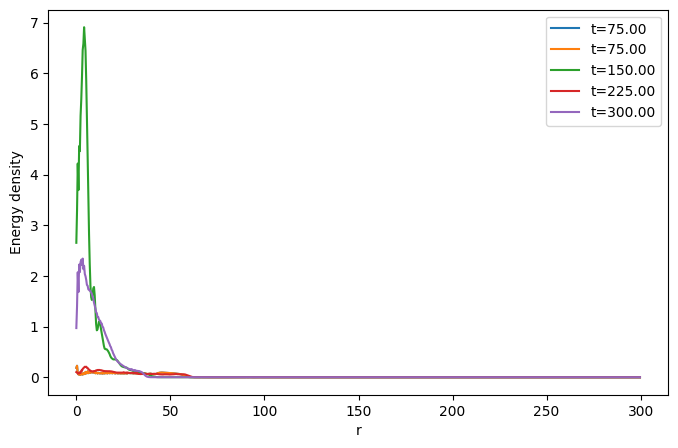

In [120]:
dr=r[1]-r[0]
indices = [len(sol.t)//4, len(sol.t)//4, len(sol.t)//2, 3*len(sol.t)//4, -1]

plt.figure(figsize=(8,5))

for k in indices:
    E = energy_density_at_k(k, sol, r, dr, n, p)
    plt.plot(r, E, label=f"t={sol.t[k]:.2f}")

plt.xlabel("r")
plt.ylabel("Energy density")
plt.legend()
plt.show()

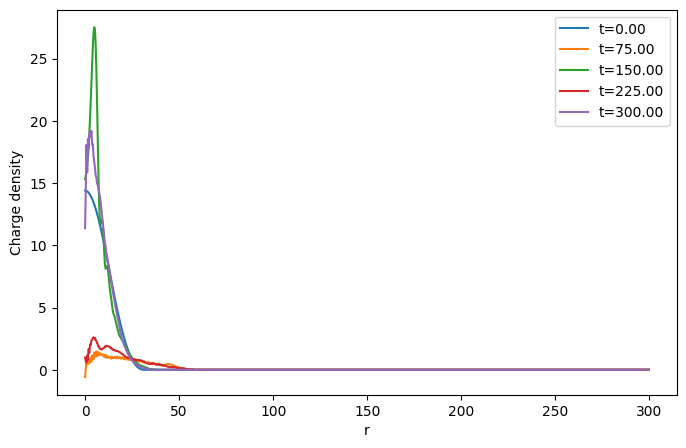

In [121]:
dr=r[1]-r[0]
indices = [0, len(sol.t)//4, len(sol.t)//2, 3*len(sol.t)//4, -1]

plt.figure(figsize=(8,5))

for k in indices:
    Q = charge_density_at_k(k, sol, r, dr, n, p)
    plt.plot(r, Q, label=f"t={sol.t[k]:.2f}")

plt.xlabel("r")
plt.ylabel("Charge density")
plt.legend()
plt.show()

In [122]:
def total_energy_vs_time(sol, r, dr, n, p):
    E_tot = []

    for k in range(len(sol.t)):
        E = energy_density_at_k(k, sol, r, dr, n, p)

        # integrate with spherical measure
        E_total = 4 * np.pi * np.sum(r**2 * E) * dr
        E_tot.append(E_total)

    return np.array(E_tot)

In [123]:
def total_charge_vs_time(sol, r, dr, n, p):
    Q_tot = []

    for k in range(len(sol.t)):
        Q = charge_density_at_k(k, sol, r, dr, n, p)

        # integrate with spherical measure
        Q_total = 4 * np.pi * np.sum(r**2 * Q) * dr
        Q_tot.append(Q_total)

    return np.array(Q_tot)

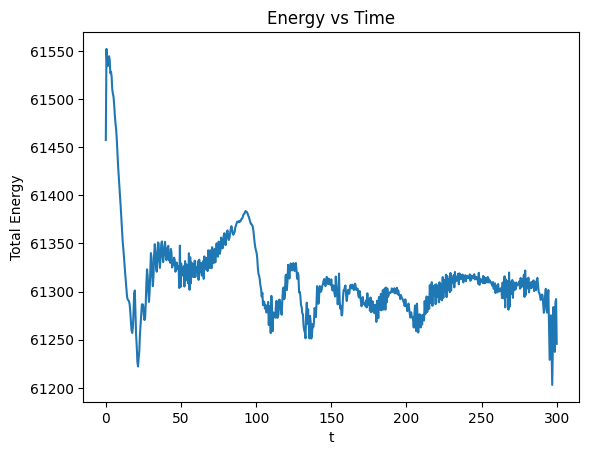

In [124]:
E_tot = total_energy_vs_time(sol, r, dr, n, p)

plt.plot(sol.t, E_tot)
plt.xlabel("t")
plt.ylabel("Total Energy")
plt.title("Energy vs Time")
plt.show()


7892.899158115556


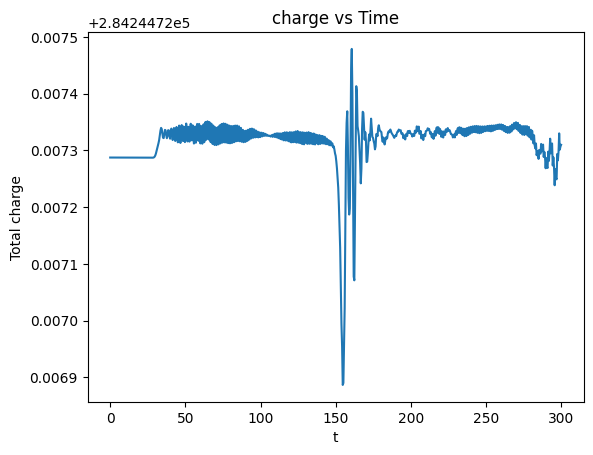

In [125]:
Q_tot = total_charge_vs_time(sol, r, dr, n, p)
print(Q0)
plt.plot(sol.t, Q_tot)
plt.xlabel("t")
plt.ylabel("Total charge")
plt.title("charge vs Time")
plt.show()


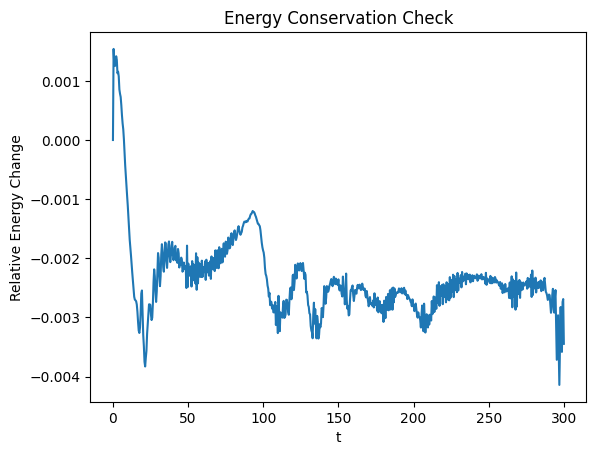

<Figure size 640x480 with 0 Axes>

In [126]:
E0 = E_tot[0]
rel_change = (E_tot - E0) / E0

plt.plot(sol.t, rel_change)
plt.xlabel("t")
plt.ylabel("Relative Energy Change")
plt.title("Energy Conservation Check")
plt.show()
plt.savefig("ec.pdf", bbox_inches='tight', dpi=300)

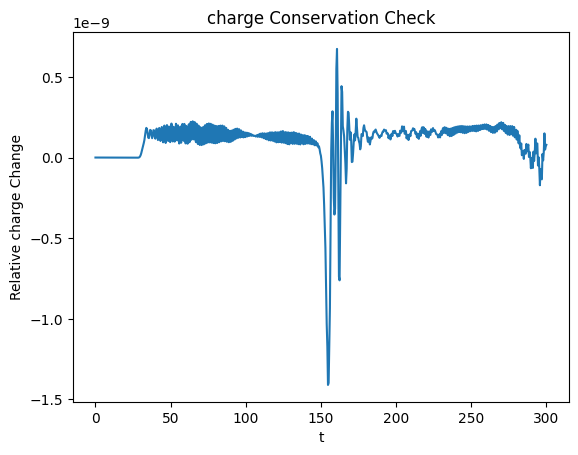

<Figure size 640x480 with 0 Axes>

In [127]:
Q0 = Q_tot[0]
rel_change = (Q_tot - Q0) / Q0
plt.plot(sol.t, rel_change)
plt.xlabel("t")
plt.ylabel("Relative charge Change")
plt.title("charge Conservation Check")
plt.show()
plt.savefig("cc.pdf", bbox_inches='tight', dpi=300)